Looking in indexes: https://mirrors.aliyun.com/pypi/simple/
Note: you may need to restart the kernel to use updated packages.
[1/4] Loading data...
Data loaded. X shape: (54256, 510), y shape: (54256,)

[2/4] Feature engineering...
After variance filtering: 53 features
After PCA: 30 features
Explained variance ratio sum: 0.99

[3/4] Model training & evaluation...

Training Logistic Regression...
Logistic Regression | AP: 0.6878 | time: 1.98s

Training Decision Tree...
Decision Tree | AP: 0.5787 | time: 1.73s

Training Random Forest...
Random Forest | AP: 0.6573 | time: 11.80s

[4/4] Drawing PR curves...


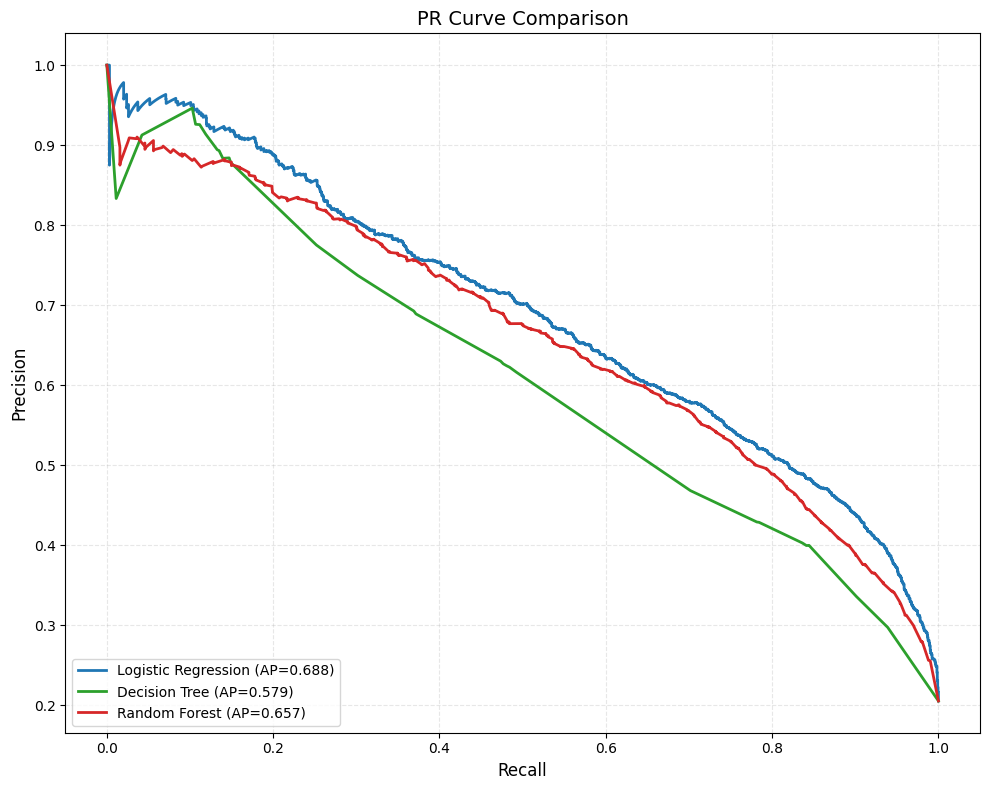

Saved figure: pr_comparison.png

Total runtime: 20.41s


In [1]:
import numpy as np
%pip install matplotlib -i https://mirrors.aliyun.com/pypi/simple/ 

import matplotlib.pyplot as plt
from time import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score

# Keep runs reproducible
np.random.seed(0)


def read_dataset():
    """Read preprocessed training features and labels from local files."""
    x_path = './data/data/X_train'
    y_path = './data/data/Y_train'

    X = np.loadtxt(x_path, delimiter=',', skiprows=1, usecols=range(1, 511))
    y = np.loadtxt(y_path, delimiter=',', skiprows=1, usecols=1)
    print(f"Data loaded. X shape: {X.shape}, y shape: {y.shape}")
    return X, y


class PipelineFeatureTransform:
    """Simple feature pipeline: variance filter -> scale -> PCA."""

    def __init__(self, var_threshold=0.1):
        self.var_filter = VarianceThreshold(threshold=var_threshold)
        self.scaler = StandardScaler()
        self.pca = PCA(n_components=0.95, svd_solver='full')

    def fit_transform(self, X):
        # 1) Drop very low-variance columns
        X_out = self.var_filter.fit_transform(X)
        print(f"After variance filtering: {X_out.shape[1]} features")

        # 2) Standardize and clip extreme values for stability
        X_out = self.scaler.fit_transform(X_out)
        X_out = np.clip(X_out, -10, 10)

        # 3) PCA: ratio-based for high-dim, fixed cap for lower dim
        if X_out.shape[1] > 1:
            if X_out.shape[1] > 100:
                self.pca.n_components = 0.95
            else:
                self.pca.n_components = min(30, X_out.shape[1] - 1)

            X_out = self.pca.fit_transform(X_out)
            print(f"After PCA: {X_out.shape[1]} features")
            print(f"Explained variance ratio sum: {self.pca.explained_variance_ratio_.sum():.2f}")
        else:
            print('Too few features for PCA, skip this step.')

        return X_out

    def transform(self, X):
        # Apply the exact same transforms learned from training set
        X_out = self.var_filter.transform(X)
        X_out = self.scaler.transform(X_out)
        X_out = np.clip(X_out, -10, 10)

        if hasattr(self.pca, 'n_components_'):
            X_out = self.pca.transform(X_out)

        return X_out


def evaluate_models(model_bank, X_train, y_train, X_test, y_test):
    """Train each model and collect PR-curve metrics."""
    records = {}

    for model_name, estimator in model_bank.items():
        print(f"\nTraining {model_name}...")
        t0 = time()

        estimator.fit(X_train, y_train)
        elapsed = time() - t0

        # Use probability score if available, else decision score
        if hasattr(estimator, 'predict_proba'):
            score = estimator.predict_proba(X_test)[:, 1]
        else:
            score = estimator.decision_function(X_test)

        precision, recall, _ = precision_recall_curve(y_test, score)
        ap = average_precision_score(y_test, score)

        records[model_name] = {
            'precision': precision,
            'recall': recall,
            'ap': ap,
            'train_time': elapsed,
        }

        print(f"{model_name} | AP: {ap:.4f} | time: {elapsed:.2f}s")

    return records


def draw_pr_comparison(summary):
    """Draw PR curves for all models on one chart."""
    plt.figure(figsize=(10, 8))
    palette = ['tab:blue', 'tab:green', 'tab:red']

    for (name, info), color in zip(summary.items(), palette):
        plt.plot(
            info['recall'],
            info['precision'],
            color=color,
            linewidth=2,
            label=f"{name} (AP={info['ap']:.3f})",
        )

    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title('PR Curve Comparison', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(loc='lower left')
    plt.tight_layout()
    plt.savefig('pr_comparison.png', dpi=150)
    plt.show()
    print('Saved figure: pr_comparison.png')


def main():
    print('[1/4] Loading data...')
    X, y = read_dataset()

    # Keep label distribution balanced in train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y,
    )

    print('\n[2/4] Feature engineering...')
    transformer = PipelineFeatureTransform(var_threshold=0.1)
    X_train_proc = transformer.fit_transform(X_train)
    X_test_proc = transformer.transform(X_test)

    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, n_jobs=-1),
        'Decision Tree': DecisionTreeClassifier(max_depth=5),
        'Random Forest': RandomForestClassifier(n_estimators=100, n_jobs=-1),
    }

    print('\n[3/4] Model training & evaluation...')
    report = evaluate_models(models, X_train_proc, y_train, X_test_proc, y_test)

    if report:
        print('\n[4/4] Drawing PR curves...')
        draw_pr_comparison(report)
    else:
        print('No valid model results to visualize.')


if __name__ == '__main__':
    t_start = time()
    main()
    print(f"\nTotal runtime: {time() - t_start:.2f}s")

